In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import scipy.sparse as sp
from sklearn.metrics import adjusted_rand_score

import sys
import os
sys.path.append(os.path.abspath('../utils'))
from ClusterAlgorithms import ClusterBy
from ClusterAlgorithms import k_LE_SC
from RandomGraph import DSBM

In [ ]:
from tqdm.notebook import tqdm
# Set DSBM parameters
k = 2
community_sizes = [1000, 1000]
N = np.sum(community_sizes)
p = 0.005
q = 0.005

num_rep = 1
eta_list = np.linspace(0,0.5,11)

ARI_SC = np.zeros((len(eta_list), num_rep))
ARI_Herm = np.zeros((len(eta_list), num_rep))
ARI_DISIM_L = np.zeros((len(eta_list), num_rep))
ARI_DISIM_R = np.zeros((len(eta_list), num_rep))
ARI_DSCORE = np.zeros((len(eta_list), num_rep))
ARI_LE_SC = np.zeros((len(eta_list), num_rep))
ARI_LE_SC_true = np.zeros((len(eta_list), num_rep))
ARI_BibSym = np.zeros((len(eta_list), num_rep))
ARI_H0_SC = np.zeros((len(eta_list), num_rep))
ARI_SimpHerm = np.zeros((len(eta_list), num_rep))

for i in tqdm(range(len(eta_list))):
  for j in range(num_rep):
    eta = eta_list[i]
    eta_matrix = np.array([[0.5, 1-eta],
                       [eta, 0.5]])
    Ad,y_true = DSBM(N, k, community_sizes, p, q, eta_matrix).generate_graph()
    GCluster = ClusterBy(Ad, k)

    y_Herm = GCluster.HermCLuster()
    y_Sym = GCluster.SpectralCluster()
    y_BibSym = GCluster.BibSym()
    y_DISIM_L, y_DISIM_R = GCluster.DISIM(reg=1)
    y_DSCORE = GCluster.DSCORE()
    y_SimpHerm = GCluster.SimpHerm()
    # Our methods
    # 1. LE-SC  (iterative LE-SC)
    y_LE_SC = k_LE_SC(Ad, k = 2, max_iter=10, init='Bal', t=0.05)

    # 2. LE-SC (oracle)
    if eta ==0:
      eta = 1e-5
    if eta ==0.5:
      eta = 0.4999999999
    w1 = np.log((1 - eta) / eta)
    w2 = -np.log(4 * eta * (1 - eta)) + 2 * np.log((p*(1-q))/ (q*(1-p)))
    w3 = 2 * np.log((1 - p) / (1 - q))
    HH = w1 * 1j * (Ad - Ad.T) + w2 * (Ad + Ad.T) + w3 * (np.ones((N, N)) - np.eye(N))
    y_LE_SC_true = GCluster.f_Herm(HH)



    ARI_SC[i,j] = adjusted_rand_score(y_true, y_Sym)
    ARI_Herm[i,j] = adjusted_rand_score(y_true, y_Herm)
    ARI_DISIM_L[i,j] = adjusted_rand_score(y_true, y_DISIM_L)
    ARI_DISIM_R[i,j] = adjusted_rand_score(y_true, y_DISIM_R)
    ARI_DSCORE[i,j] = adjusted_rand_score(y_true, y_DSCORE)
    ARI_SimpHerm[i,j] = adjusted_rand_score(y_true, y_SimpHerm)
    ARI_BibSym[i,j] = adjusted_rand_score(y_true, y_BibSym)
    ARI_LE_SC[i,j] = adjusted_rand_score(y_true, y_LE_SC)
    ARI_LE_SC_true[i,j] = adjusted_rand_score(y_true, y_LE_SC_true)


  0%|          | 0/11 [00:00<?, ?it/s]

Iterative LE-SC converged within 3 iterations.
Iterative LE-SC converged within 3 iterations.
Iterative LE-SC converged within 3 iterations.
Iterative LE-SC converged within 3 iterations.
Iterative LE-SC converged within 4 iterations.
Iterative LE-SC converged within 4 iterations.
Iterative LE-SC converged within 4 iterations.
Iterative LE-SC converged within 4 iterations.
Iterative LE-SC converged within 4 iterations.
Iterative LE-SC converged within 4 iterations.
Iterative LE-SC converged within 4 iterations.


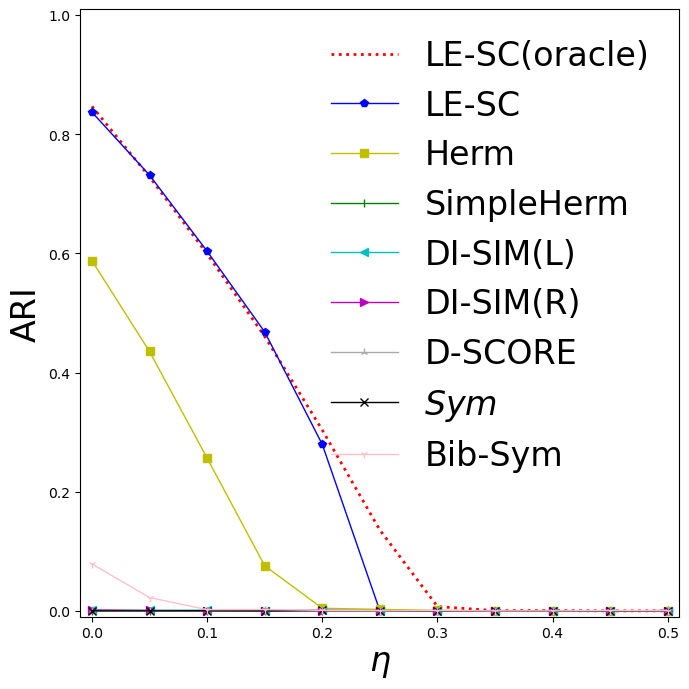

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(7, 7))
plt.plot(eta_list, np.mean(ARI_LE_SC_true, axis=1), label='LE-SC(oracle)',linestyle = ':',linewidth = 2, color = 'r')
plt.plot(eta_list, np.mean(ARI_LE_SC, axis=1), label='LE-SC',marker = 'p',linewidth = 1, color = 'b')
plt.plot(eta_list, np.mean(ARI_Herm, axis=1), label='Herm', linewidth = 1, marker = 's', color = 'y' )
plt.plot(eta_list, np.mean(ARI_SimpHerm, axis=1), label='SimpleHerm', marker = '|',linewidth = 1,color = 'green')
plt.plot(eta_list, np.mean(ARI_DISIM_L, axis=1), label='DI-SIM(L)',marker = '<', linewidth = 1, color = 'c')
plt.plot(eta_list, np.mean(ARI_DISIM_R, axis=1), label='DI-SIM(R)',marker = '>',linewidth = 1, color = 'm')
plt.plot(eta_list, np.mean(ARI_DSCORE, axis=1), label='D-SCORE',marker = '2', linewidth = 1, color = 'darkgray')
plt.plot(eta_list, np.mean(ARI_SC, axis=1), label='$Sym$', marker = 'x', linewidth = 1, color = 'black')
plt.plot(eta_list, np.mean(ARI_BibSym, axis=1), label='Bib-Sym', marker = '1',linewidth = 1, color = 'pink')

plt.xlabel('$\eta$', fontsize = 24)
plt.ylabel('ARI', fontsize = 24)
# plt.title(f'DSBM ($p$={p*100}%, $q$={q*100}%)',  fontsize = 20)
plt.legend(fontsize=24, frameon=False, loc='upper right')
plt.xlim(-0.01, 0.5+0.01)
plt.ylim(-0.01,1+0.01)
plt.tight_layout()
